# <center> Линейная алгебра в контексте линейных методов. Практика.

## <center> Прогнозирование выработки газа на скважинах.

## Постановка задачи

У Василия, основателя компании «Газ-Таз-Ваз-Нефть», дела идут в гору: у него уже функционирует 200 скважин для добычи газа. В этом году он открывает 30 новых скважин. Однако в целях оптимизации расходов и повышения дохода Василию необходимо оценить, сколько денег будет приносить ему каждая из скважин, а также понять, какие факторы (параметры скважин) потенциально сильнее всего повлияют на объём добычи газа. Для этого Василий решил нанять вас как специалиста в области Data Science.

Василий представляет вам набор данных о добыче газа на своих скважинах. Файл с данными вы можете скачать на платформе.

**Признаки в данных:**

* Well — идентификатор скважины;
* Por — пористость скважины (%);
* Perm — проницаемость скважины;
* AI — акустический импеданс ($кг/м^2 * 10^6$);
* Brittle — коэффициент хрупкости скважины (%);
* TOC — общий органический углерод (%);
* VR — коэффициент отражения витринита (%);
* Prod — добыча газа в сутки (млн. кубических футов).

**Ваша задача** — построить регрессионную модель, которая прогнозирует выработку газа на скважине (целевой признак — Prod) на основе остальных характеристик скважины, и проинтерпретировать результаты вашей модели.

Разделим задачу на две части:
* В первой мы построим простейшую модель линейной регрессии, проанализируем результаты её работы и выберем наиболее значимые факторы для прогнозирования.
* Во второй мы займёмся построением модели полиномиальной регрессии с регуляризацией и посмотрим на итоговые результаты моделирования.


Импортируем необходимые библиотеки:

In [121]:
# Импорт библиотек
import numpy as np # для работы с массивами
import pandas as pd # для работы с DataFrame 
import seaborn as sns # библиотека для визуализации статистических данных
import matplotlib.pyplot as plt # для построения графиков
import plotly.express as px
import plotly.graph_objects as go

Прочитаем исходные данные:

In [122]:
df = pd.read_csv(r'C:\Users\user\Desktop\Skilfactory\data1\unconv.csv')
df.head()

,Well,Por,Perm,AI,Brittle,TOC,VR,Prod
0,1,12.08,2.92,2.80,81.40,1.16,2.31,4165.196191
1,2,12.38,3.53,3.22,46.17,0.89,1.88,3561.146205
2,3,14.02,2.59,4.01,72.80,0.89,2.72,4284.348574
3,4,17.67,6.75,2.63,39.81,1.08,1.88,5098.680869
4,5,17.52,4.57,3.18,10.94,1.51,1.90,3406.132832


## Практика: линейная регрессия по методу наименьших квадратов

Для начала построим простейшую модель линейной регрессии, проанализируем результаты её работы и выберем наиболее значимые факторы для прогнозирования.

В первой части вам предстоит выполнить задания 5.0–5.6. Максимальное количество баллов, которое можно получить, — 9.

### Задание 5.0. (не оценивается)

Проведите небольшой разведывательный анализ, чтобы поближе познакомиться с исходными данными. Постройте несколько визуализаций, которые помогут вам понять, как устроены исходные признаки, а также смогут продемонстрировать взаимосвязь факторов. 

Сделайте промежуточные выводы из проведённого разведывательного анализа.

In [123]:
df.info()
df_copy = df.copy()
# Пропусков нет

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Well     200 non-null    int64  
 1   Por      200 non-null    float64
 2   Perm     200 non-null    float64
 3   AI       200 non-null    float64
 4   Brittle  200 non-null    float64
 5   TOC      200 non-null    float64
 6   VR       200 non-null    float64
 7   Prod     200 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 12.6 KB


In [124]:
data_dict = {
    'Por': 'пористость скважины (%)',
    'Perm': 'проницаемость скважины', 
    'AI': 'акустический импеданс (кг/м² * 10⁶)',
    'Brittle': 'коэффициент хрупкости скважины (%)',
    'TOC': 'общий органический углерод (%)',
    'VR': 'коэффициент отражения витринита (%)',
}

In [125]:
features = ['Por', 'Perm', 'AI', 'Brittle', 'TOC', 'VR']
fig = px.histogram(df, x='Por', title='Распределение признака - Por')
fig.update_layout(xaxis_title='Значение', yaxis_title='Частота')
buttons = []
for feature in features:
    buttons.append(dict(method='update', label=feature, args=[{'x': [df[feature]]}, {'title' : f'Распределение признака - {feature}: ({data_dict[feature]})',
                                                                                     'xaxis.title' : f'Значение признака - {feature}: ({data_dict[feature]}',
                                                                                     'yaxis.title' : f'Частота'}]))
    
fig.update_layout(
    updatemenus=[dict(type='dropdown', direction='down', x=1, y=1.15, buttons=buttons)])
fig.show()

Графики практически всех признаков имеют явную форму нормального распределение, что без сомнение сильно облегчит дальнейшую работу. Поэтому удалим выбросы с помощью метода 3 сигм

In [126]:
def three_sigma(df, column):
    sigma = np.std(df[column])
    mean_ = np.mean(df[column])
    upper_side = mean_ + 3 * sigma
    lower_side = mean_ - 3 * sigma
    inliers = (df[column] > lower_side) & (df[column] < upper_side)
    return inliers

mask_all = pd.Series([True] * len(df), index=df.index)
for col in ['Por', 'Perm', 'AI', 'Brittle', 'TOC', 'VR', 'Prod']:
    mask_col = three_sigma(df, col)
    mask_all = mask_all & mask_col  
df_clean = df[mask_all].copy()
df_clean

,Well,Por,Perm,AI,Brittle,TOC,VR,Prod
0,1,12.08,2.92,2.80,81.40,1.16,2.31,4165.196191
1,2,12.38,3.53,3.22,46.17,0.89,1.88,3561.146205
2,3,14.02,2.59,4.01,72.80,0.89,2.72,4284.348574
3,4,17.67,6.75,2.63,39.81,1.08,1.88,5098.680869
4,5,17.52,4.57,3.18,10.94,1.51,1.90,3406.132832
...,...,...,...,...,...,...,...,...
194,195,17.13,5.99,2.88,51.45,1.77,2.28,5489.491177
195,196,11.95,3.13,2.97,67.18,0.80,2.06,3847.571003
197,198,12.12,2.27,3.52,57.07,-0.04,1.73,3409.575363
198,199,15.55,4.48,2.48,58.25,1.89,2.35,5087.592149


Построим scatterplot для признаков и посмотрим на корреляционную связь.

In [127]:
features = ['Por', 'Perm', 'AI', 'Brittle', 'TOC', 'VR']
fig = px.scatter(df, x='Por', y='Prod', title='Корреляционное поле признаков')
fig.update_layout(xaxis_title = 'Пористость', yaxis_title='Объём добычи газа')
buttons = []
for feature in features:
    buttons.append(dict(method='update', label=feature, args=[{'x' : [df[feature]]},
                                                              {'title' : f'Корреляционное поле признака {feature}: ({data_dict[feature]}) и объёма добычи газа',
                                                               'xaxis.title' : f'Признак {feature}: ({data_dict[feature]})',
                                                                'yaxis.title' : f'Добыча газа в млн м^3'}]
                        ))
fig.update_layout(
    updatemenus=[dict(type='dropdown', direction='down', x=1.1, y=1, buttons=buttons)]
)
fig.show()

### Задание 5.1. (2 балла)

Постройте корреляционную матрицу факторов, включив в неё целевой признак. 

Для наглядности визуализируйте полученную матрицу с помощью тепловой карты. 

**Примечание.** *Для визуализации вы можете использовать любую из знакомых вам библиотек.*

На основе построенной корреляционной матрицы ответьте на следующий вопрос:

* Какие факторы сильнее всего коррелируют с целевой переменной?

Вычислите ранг и определитель полученной матрицы корреляций и приведите развёрнутые ответы на следующие вопросы:
* Является ли корреляционная матрица плохо обусловенной (близок ли её опредитель к нулю)?
* Что вы можете сказать о наличии коллинераности/мультиколлинеарности в данных? 
* Применима ли в данном случае модель классической линейной регрессии по методу наименьших квадратов и почему? 

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * приведён код для расчёта корреляционной матрицы;
    * приведён код для визуализации корреляционной матрицы в виде тепловой карты;
    * рассчитаны ранг и определитель корреляционной матрицы;
    * предоставлены обоснованные ответы на все поставленные вопросы. 

- Задание выполнено верно, но не учтено одно условие (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

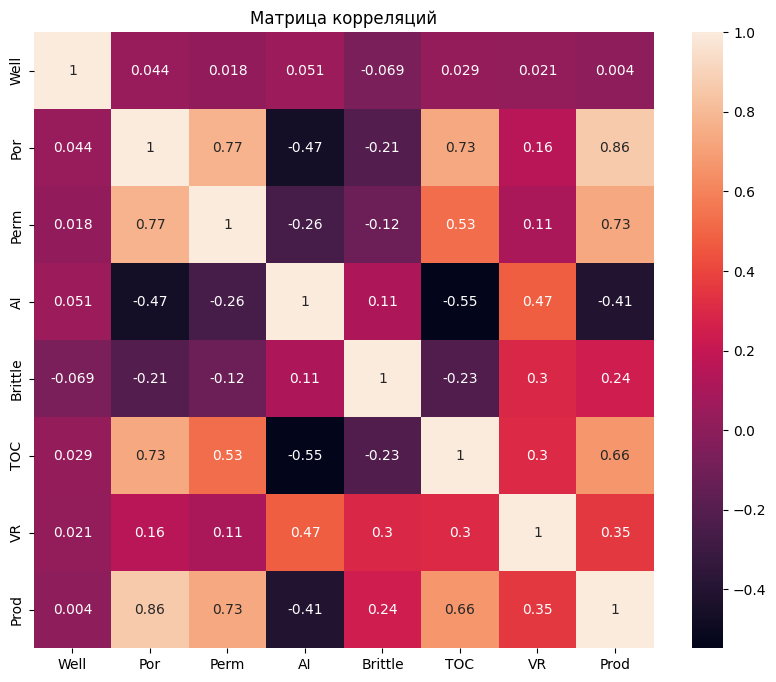

In [128]:
plt.figure(figsize=(10, 8))
plt.title('Матрица корреляций')
sns.heatmap(df_clean.corr(), annot=True)
plt.show()

Высокая и заметная корреляция между целевой переменной и признаками:
* Por(пористость) - 0.86
* Perm(проницаемость скважины) - 0.73
* TOC(общий органический углерод) - 0.66

Умеренная и слабая корреляция наблюдается:
* AI(акустический импеданс) - (-0.41)
* VR(коэффициент отражения витринита) - 0.35
* Brittle(коэффициент хрупкости скважины) - 0.24


 Какие факторы сильнее всего коррелируют с целевой переменной?

Вычислите ранг и определитель полученной матрицы корреляций и приведите развёрнутые ответы на следующие вопросы:
* Является ли корреляционная матрица плохо обусловенной (близок ли её опредитель к нулю)?
* Что вы можете сказать о наличии коллинераности/мультиколлинеарности в данных? 
* Применима ли в данном случае модель классической линейной регрессии по методу наименьших квадратов и почему? 

In [129]:
A = df.corr()
print(f'Ранг матрицы корреляций: {np.linalg.matrix_rank(A)}')
print(f'Определитель матрицы корреляций: {np.linalg.det(A)}')


Ранг матрицы корреляций: 8
Определитель матрицы корреляций: 0.0007299388072652095


Ранг матрицы = 8, что равняется количеству признаков. Это означает, что чистой коллинеарности между признаками нет, то есть векторы признаков ЛНЗ. Однако при этом определитель матрицы примерно равен 0, матрица вырожденна. Проблема мультиколлинеарности осталась, так как некоторые признаки имеют высокую корреляцию (больше 0.7). В данной ситуации от МНК лучше отказаться, так как мы имеем потенциально неустойчивое решение.  

### Задание 5.2. (2 балла)

Создайте матрицу наблюдений `X` и вектор правильных ответов `y`. В качестве факторов для матрицы наблюдений возьмите все имеющиеся в данных признаки. 

Постройте модель линейной регрессии по методу наименьших квадратов. Для этого воспользуйтесь матричной формулой МНК и инструментарием библиотеки numpy. 

Выведите на экран полученные оценки коэффициентов модели, округлённые до целого.

Приведите подробные выводы по полученным результатам, ответив на следующие вопросы:
* Есть ли в ваших данных признаки, которые, согласно модели, можно назвать неинформативными, то есть они не оказывают влияния на целевую переменную или оказывают шумовое влияние?
* Приведите интерпретацию нескольких (двух или трёх) коэффициентов полученной модели линейной регрессии.


**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * приведён код для нахождения параметров модели линейной регрессии с помощью матричной формулы МНК;
    * на основе полученных параметров даны верные ответы на поставленные вопросы;
    * приведена корректная интерпретация нескольких коэффициентов полученной модели линейной регрессии.

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [130]:
X = df_clean.drop('Prod', axis=1)
y = df_clean['Prod']

# Напишем функцию МНК
def linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    Q = np.linalg.inv(X.T @ X)
    w = Q @ X.T @ y
    return np.round(w)

w = linear_regression(X, y)
print(f'Коэффииценты регрессии: {w}')
X

Коэффииценты регрессии: [-1245.     0.   233.   108.  -358.    25.   -76.   773.]


,Well,Por,Perm,AI,Brittle,TOC,VR
0,1,12.08,2.92,2.80,81.40,1.16,2.31
1,2,12.38,3.53,3.22,46.17,0.89,1.88
2,3,14.02,2.59,4.01,72.80,0.89,2.72
3,4,17.67,6.75,2.63,39.81,1.08,1.88
4,5,17.52,4.57,3.18,10.94,1.51,1.90
...,...,...,...,...,...,...,...
194,195,17.13,5.99,2.88,51.45,1.77,2.28
195,196,11.95,3.13,2.97,67.18,0.80,2.06
197,198,12.12,2.27,3.52,57.07,-0.04,1.73
198,199,15.55,4.48,2.48,58.25,1.89,2.35


Несмотря на практически нулевой детерминант обратной матрицы, мы получили вполне адекватное решение. Однако среди коэффициентов регрессии мы видим один нулевой, Этот параметр отвечает за переменную Well (Идентификатор шахты), очевидно, что он не несет никакой информации для нашей модели, поэтому коэффициент равен 0. Все остальные переменные вносят какую-то объясняющую составляющую в предсказание уровня добычи газа из скважины, поэтому они не равны 0. Отметим ещё, что данные находятся в различных масштабах, что не даёт адекватного понимания какие из признаков вносят наибольший вклад в целевую переменную. 

Интерпретация:
1) Por (пористость скважины): При изменении пористости скважины на 1% добыча газа в сутки в среднем изменяется на 233 млн кубических футов при отсутствии изменений в других признаках.

2) Perm (проницаемость скважины): При изменении проницаемости скважины на 1 условную единицу добыча газа в сутки в среднем изменяется на 108 млн кубических футов при отсутствии изменений в других признаках.

3) TOC (общий органический углерод): При изменении общего органического углерода на 1% добыча газа в сутки в среднем изменяется на -76 млн кубических футов при отсутствии изменений в других признаках.

### Задание 5.3. (1 балл)

Теперь потренируемся строить предсказание для наблюдений целевой переменной. 

**а)** Постройте прогноз выработки газа для скважины со следующими параметрами:

```python
{
    'Well': 106.0,
    'Por': 15.32,
    'Perm': 3.71,
    'AI': 3.29,
    'Brittle': 55.99,
    'TOC': 1.35,
    'VR': 2.42
 }
```

Рассчитайте абсолютную ошибку построенного вами прогноза для предложенной скважины (в миллионах кубических футов в день), если известно, что на этой скважине производится `4748.315024` миллионов кубических футов газа в день. 

**б)** Постройте прогноз выработки газа для всех скважин из обучающего набора данных. Выберите метрику, по которой вы будете оценивать качество регрессионных моделей и сравнивать их между собой (можно использовать несколько метрик, но не более двух).

Рассчитайте значение выбранной метрики для вашей модели. Приведите интерпретацию полученного результата. 

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * приведён код для построения прогноза выработки газа на указанной скважине и рассчитана абсолютная ошибка прогноза для этой скважины;
    * выбрана корректная для поставленной задачи метрика (или метрики) оценки качества модели и приведён код для расчёта этой метрики на всём обучающем наборе данных;
    * приведена корректная интерпретация полученного результата.

- Задание выполнено верно, но не учтено одно из условий, или задание выполнено неверно (**0 баллов**).

In [131]:
features_dict = {'one': 1, 'Well': 106.0, 'Por': 15.32, 'Perm': 3.71, 'AI': 3.29, 'Brittle': 55.99, 'TOC': 1.35, 'VR': 2.42}
X_vector = [features_dict['one'], features_dict['Well'], features_dict['Por'], features_dict['Perm'], features_dict['AI'], features_dict['Brittle'], features_dict['TOC'], features_dict['VR']]

y_pred = np.dot(w, X_vector)
print(f'Прогноз выработки для новых данных: {y_pred}')
y_true = 4748.315024
print(f'Абсолютная ошибка: {np.round(abs(y_pred - y_true), 3)}')

# Расчет прогноза для всех скважин
def predict_reg(X, w):
    X_ones = np.column_stack([np.ones(X.shape[0]), X])
    return X_ones @ w
y_pred_all = predict_reg(X, w)

# Расчёт метрик
MSE_mean = np.sum((y - np.mean(y))**2) / len(y)
MSE = np.sum((y - y_pred_all)**2) / len(y)
print(f'Средняя абсолютная процентная разница (MAPE): {np.round(np.sum((np.abs(y - y_pred_all)/y) / len(y)) * 100, 2)}%')
print(f'Коэффициент детерминации (R^2): {np.round(1 - MSE/MSE_mean,2)}')

Прогноз выработки для новых данных: 4715.23
Абсолютная ошибка: 33.085
Средняя абсолютная процентная разница (MAPE): 3.63%
Коэффициент детерминации (R^2): 0.96


Метрики показывают, что в выбранная модель очень хорошо аппроксимирует данные. Средняя абсолютная процентная ошибка составляет 3.63%, то есть модель в среднем ошибается всего на 3.63% от реальных данных. Коэффициент детерминации, который показывает % объясненной дисперсии, составляет 96%, что является очень высоким показателем.

### Задание 5.4. (1 балл)

Настало время анализа построенной модели. Посмотрите на коэффициенты и сравните их знаки со значениями выборочных корреляций между целевым признаком и факторами, которые вы нашли ранее.

Дайте развёрнутые ответы на следующие вопросы:

* Есть ли в вашей модели фактор, при котором коэффициент в модели линейной регрессии противоречит соответствующему коэффициенту корреляции? Например, корреляция говорит, что зависимость между фактором и целевой переменной прямая, а модель говорит обратное. Если таких факторов несколько, укажите их все.
* Как вы считаете, с чем связано полученное противоречие результатов?

**Критерии оценивания:**

- Задание выполнено верно, даны корректные развёрнутые ответы на все поставленные в задании вопросы (**1 балл**). 

- Задание выполнено неверно, даны некорректные ответы на один или несколько поставленных в задании вопросов (**0 баллов**).

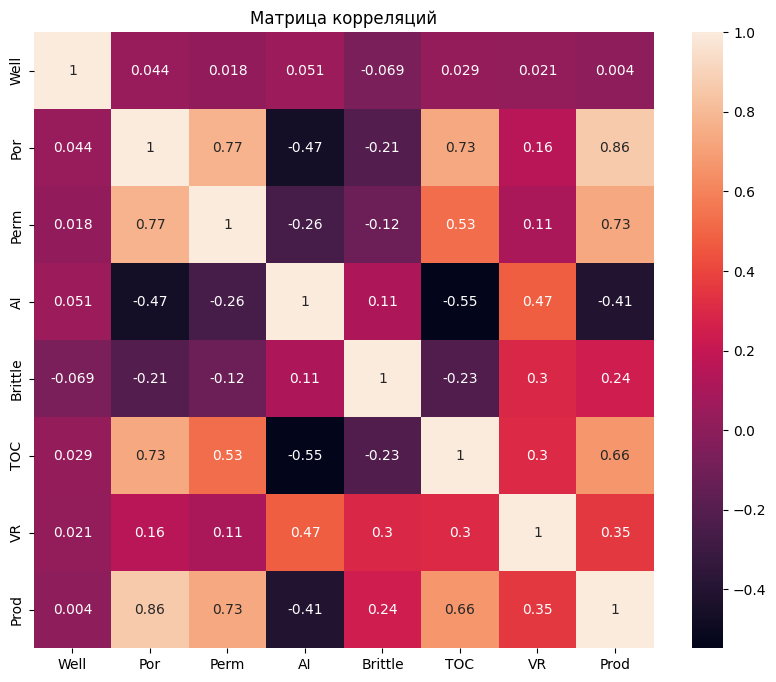

In [132]:
plt.figure(figsize=(10, 8))
plt.title('Матрица корреляций')
sns.heatmap(df_clean.corr(), annot=True)
plt.show()

In [133]:
print(f'Коэффииценты регрессии: {w}')
X

Коэффииценты регрессии: [-1245.     0.   233.   108.  -358.    25.   -76.   773.]


,Well,Por,Perm,AI,Brittle,TOC,VR
0,1,12.08,2.92,2.80,81.40,1.16,2.31
1,2,12.38,3.53,3.22,46.17,0.89,1.88
2,3,14.02,2.59,4.01,72.80,0.89,2.72
3,4,17.67,6.75,2.63,39.81,1.08,1.88
4,5,17.52,4.57,3.18,10.94,1.51,1.90
...,...,...,...,...,...,...,...
194,195,17.13,5.99,2.88,51.45,1.77,2.28
195,196,11.95,3.13,2.97,67.18,0.80,2.06
197,198,12.12,2.27,3.52,57.07,-0.04,1.73
198,199,15.55,4.48,2.48,58.25,1.89,2.35


Да, в моей модели есть фактор, при котором коэффициент в модели линейной регрессии противоречит соответствующему коэффициенту корреляции - это TOC(общий органический углерод (%)). Значение коэффициента регрессии равняется -76, а коэффициент корреляции = 0.66. Это связано с тем, что матрица (A.T @ A) плохо обусловлена и её определеитель близок к нулю. Между признаками до сих пор остаётся высокая мультиколлинеарность, которая мешает нашему алгоритму получать правильные коэффициенты.

### Задание 5.5. (2 балла)

* Исключите из данных сильно коррелированные между собой факторы. Под сильной корреляцией в данной задаче будем понимать значения выше `0.7`.

Выбирая, какой из коррелированных факторов оставить, руководствуйтесь коэффициентом корреляции с целевой переменной: оставляйте тот фактор, который больше всего коррелирует с целевой переменной (объёмом добычи газа).

* Также исключите из данных факторы, для которых корреляция с целевой переменной меньше `0.05`.

Постройте модель линейной регрессии на обновлённых после удаления факторов данных по методу наименьших квадратов. Для этого используйте матричную формулу и библиотеку numpy. Выведите значение полученных коэффициентов, округлённых до целого.

Сделайте прогноз для всего обучающего набора данных и рассчитайте выбранную вами ранее метрику (или метрики). 

Дайте подробные ответы на следующие вопросы:

* Приведите интерпретацию нескольких полученных коэффициентов (двух или трёх). Сравните их значения с полученными ранее.
* Приведите интерпретацию полученных значений метрик. Сравните их значения с полученными ранее. 
* Удалось ли вам побороть противоречие коэффициентов линейной регрессии и коэффициентов корреляции?

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * отобраны верные факторы;
    * на основе отобранных факторов построена модель линейной регрессии с помощью матричной формулы МНК и найдены параметры модели, соответствующие каждому из факторов;
    * построен прогноз для всего обучающего набора данных и рассчитано значение метрики (метрика должна быть выбрана корректно);
    * даны ответы на все поставленные в задании вопросы.

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено верно, не учтено несколько из условий (**0 баллов**).

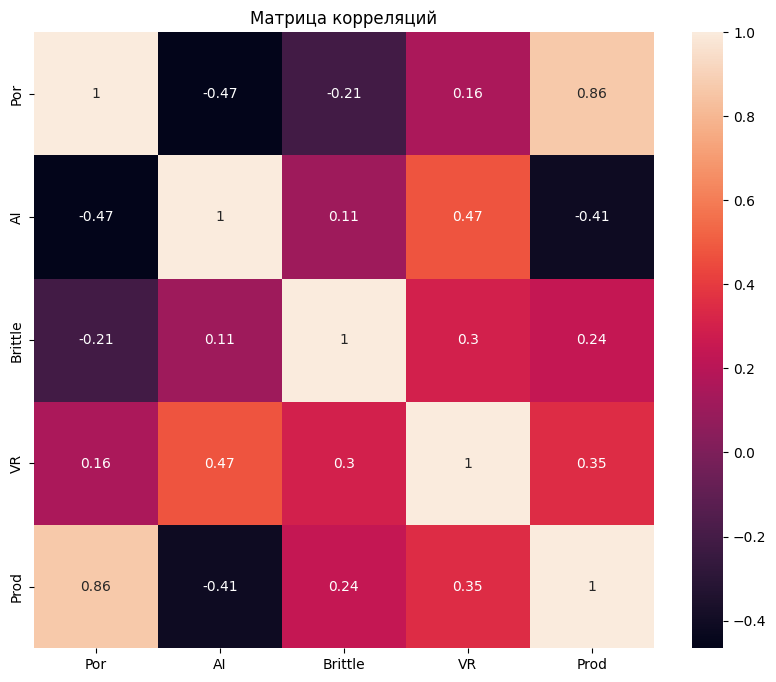

In [134]:
# Удалим сильно скоррелированные и неинформативные признаки
df_clean.drop(['Perm', 'TOC', 'Well'], axis=1, inplace=True)

plt.figure(figsize=(10, 8))
plt.title('Матрица корреляций')
sns.heatmap(df_clean.corr(), annot=True)
plt.show()

In [135]:
X = df_clean.drop('Prod', axis=1)
y = df_clean['Prod']
w = linear_regression(X, y)
print(f'Коэффииценты регрессии: {w}')
X

Коэффииценты регрессии: [-1724.   286.  -226.    27.   560.]


,Por,AI,Brittle,VR
0,12.08,2.80,81.40,2.31
1,12.38,3.22,46.17,1.88
2,14.02,4.01,72.80,2.72
3,17.67,2.63,39.81,1.88
4,17.52,3.18,10.94,1.90
...,...,...,...,...
194,17.13,2.88,51.45,2.28
195,11.95,2.97,67.18,2.06
197,12.12,3.52,57.07,1.73
198,15.55,2.48,58.25,2.35


In [136]:
y_pred_all_clean = predict_reg(X, w)

# Расчёт метрик
MSE_mean = np.sum((y - np.mean(y))**2) / len(y)
MSE = np.sum((y - y_pred_all_clean)**2) / len(y)
print(f'Средняя абсолютная процентная разница (MAPE): {np.round(np.sum((np.abs(y - y_pred_all_clean)/y) / len(y)) * 100, 2)}%')
print(f'Коэффициент детерминации (R^2): {np.round(1 - MSE/MSE_mean,2)}')

Средняя абсолютная процентная разница (MAPE): 3.95%
Коэффициент детерминации (R^2): 0.95


Интерпретация:
1) Por (пористость скважины): При изменении пористости скважины на 1% добыча газа в сутки в среднем изменяется на 286 млн кубических футов при отсутствии изменений в других признаках.

2) AI — акустический импеданс ($кг/м^2 * 10^6$): При изменении акустического импеданса скважины на 1 $кг/м^2 * 10^6$ добыча газа в сутки в среднем изменяется на -226 млн кубических футов при отсутствии изменений в других признаках.

3) Brittle — коэффициент хрупкости скважины (%): При изменении коэффициента хрупкости скважины на 1% добыча газа в сутки в среднем изменяется на 27 млн кубических футов при отсутствии изменений в других признаках.

Метрики показывают, что данная модель очень хорошо аппроксимирует данные. Средняя абсолютная процентная ошибка составляет 3.95%, что чуть хуже предыдущей модели (3,63%), то есть модель в среднем ошибается всего на 3.95% от реальных данных. Коэффициент детерминации, который показывает % объясненной дисперсии, составляет 95%, что также чуть хуже предыдущей модели (96%), что является очень высоким показателем.

Однако нам удалось побороть противоречия между коэффициентами корреляции и коэффициентами регрессии. Теперь каждый признак соответствует значению корреляции.

### Задание 5.6. (1 балл)

Наконец, давайте построим модель линейной регрессии из библиотеки `scikit-learn (sklearn)` и сравним результаты её работы с теми, что нам удалось получить вручную. 

Постройте модель линейной регрессии на обновлённых после удаления факторов данных по методу наименьших квадратов. Для этого воспользуйтесь классом `LinearRegression` из библиотеки `sklearn`. Выведите значения полученных коэффициентов, округлённые до целого.

Сделайте прогноз для всего обучающего набора данных и рассчитайте значение выбранной вами метрики (или метрик).

Сравните результаты библиотечной реализации с тем, что вы получили ранее. 

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**1 балл**): 
    * на основе отобранных факторов построена модель линейной регрессии из библиотеки sklearn и найдены параметры модели, соответствующие каждому из факторов;
    * построен прогноз для всего обучающего набора данных и рассчитано значение метрики (метрика должна быть выбрана корректно);
    * приведён вывод о соответствии результатов, полученных вручную и с помощью библиотеки.
- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [137]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate
from sklearn import metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
lin_reg = LinearRegression()
lin_reg.fit(X, y)
print(f'Свободный член: {np.round(lin_reg.intercept_)}')
print(f'Коэффициенты регрессии: {np.round(lin_reg.coef_)}')

Свободный член: -1724.0
Коэффициенты регрессии: [ 286. -226.   27.  560.]


In [138]:
y_pred_sk = lin_reg.predict(X)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print(f'Средняя абсолютная процентная разница (MAPE): {np.round(metrics.mean_absolute_percentage_error(y, y_pred_sk), 4) * 100}%')
print(f'Коэффициент детерминации (R^2): {np.round(metrics.r2_score(y, y_pred_sk), 2)}')

Средняя абсолютная процентная разница (MAPE): 3.94%
Коэффициент детерминации (R^2): 0.95


Значение коэффициентов регрессии, полученных расчетом вручную и с помощью класса LinearRegression полностью совпадают.
Аналогичная ситуация и с метриками. R^2 полностью совпадает, MAPE есть небольшая погрешность в 1 сотой, скорее всего из-за округлений.

In [139]:
# Для последнего задания
cv = cross_validate(LinearRegression(), X=X, y=y, 
                    scoring={'r2' : 'r2', 'neg_mape' : make_scorer(mean_absolute_percentage_error, greater_is_better=False)}, 
                    return_train_score=True, cv=5)
print(f'R^2 на тренировочных фолдах: {np.round(np.mean(cv['train_r2']), 3)}')
print(f'R^2 на валидационных фолдах: {np.round(np.mean(cv['test_r2']), 3)}')
print(f'MAPE на тренировочных фолдах: {np.round(np.mean(-cv['train_neg_mape']) * 100, 3)}%')
print(f'MAPE на валидационных фолдах: {np.round(np.mean(-cv['test_neg_mape']) * 100, 3)}%')

R^2 на тренировочных фолдах: 0.949
R^2 на валидационных фолдах: 0.94
MAPE на тренировочных фолдах: 3.915%
MAPE на валидационных фолдах: 4.154%


## Практика: полиномиальная регрессия и регуляризация

Мы продолжаем работать над задачей от владельца компании «Газ-Таз-Ваз-Нефть» Василия.

Ранее мы построили модель линейной регрессии, которая прогнозирует выработку газа на скважине. Для этого мы с помощью матрицы корреляций и рассуждений отобрали некоррелированные, значимые для предсказания признаки. **Далее мы будем использовать именно их (см. задание 5.5).**

Мы хотим улучшить результат — уменьшить ошибку прогноза. Для этого мы воспользуемся моделью полиномиальной регрессии третьей степени. Однако теперь мы знаем, что полиномиальным моделям очень легко переобучиться под исходную выборку. Так как данных у нас не так много (всего 200 скважин), то для контроля качества модели мы будем использовать кросс-валидацию. 

Приступим! Выполните задания 8.1–8.5:


In [140]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate

### Задание 8.1. (1 балл)

Стандаризируйте признаки с помощью `StandartScaler` из библиотеки `sklearn`. 

Затем сгенерируйте полиномиальные признаки третьего порядка на факторах, которые вы выбрали для обучения моделей. Для этого воспользуйтесь генератором полиномов `PolynomialFeatures` из библиотеки `sklearn`. Параметр `include_bias` установите в значение `False`.

Выведите на экран, сколько факторов у вас получилось после генерации полиномиальных признаков.

**Важно:** стандартизацию необходимо произвести до генерации полиномиальных факторов!

Обучите модель линейной регрессии из библиотеки `sklearn` (`LinearRegression`) на полученных полиномиальных факторах.

Используя кросс-валидацию оцените среднее значение выбранной вами метрики (или метрик) на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**1 балл**): 
    * на основе отобранных факторов сгенерированы полиномиальные признаки третьего порядка;
    * построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).
- Задание выполнено неверно, не учтено одно или несколько из условий (**0 баллов**).

In [141]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
r_scaler = StandardScaler()
X = r_scaler.fit_transform(X)

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)
print(f'Количество факторов: {X_poly.shape[0]}')

# Кросс-валидация
cv = cross_validate(LinearRegression(), X=X_poly, y=y, 
                    scoring={'r2' : 'r2', 'neg_mape' : make_scorer(mean_absolute_percentage_error, greater_is_better=False)}, 
                    return_train_score=True, cv=5)
print(f'R^2 на тренировочных фолдах: {np.round(np.mean(cv['train_r2']), 3)}')
print(f'R^2 на валидационных фолдах: {np.round(np.mean(cv['test_r2']), 3)}')
print(f'MAPE на тренировочных фолдах: {np.round(np.mean(-cv['train_neg_mape']) * 100, 3)}%')
print(f'MAPE на валидационных фолдах: {np.round(np.mean(-cv['test_neg_mape']) * 100, 3)}%')

Количество факторов: 195
R^2 на тренировочных фолдах: 0.991
R^2 на валидационных фолдах: 0.976
MAPE на тренировочных фолдах: 1.698%
MAPE на валидационных фолдах: 2.665%


Для полиномиальной регрессии 3 степени мы использовали 195 факторов. Оценки R^2 и MAPE как на тренировочных фолдах, так и на валидационных очень высокие, переобучение очень слабое, можно сказать, что его нет.

### Задание 8.2. (2 балла)

Теперь попробуем воспользоваться линейной регрессией с регуляризацией. Для начала возьмём $L_1$-регуляризацию.

Обучите модель `Lasso` из библиотеки `sklearn` на полученных полиномиальных факторах, предварительно стандартизировав факторы. 

Коэффициент регуляризации (`alpha`) подберите самостоятельно с помощью любого известного вам метода подбора гиперпаметров.

Используя кросс-валидацию, оцените среднее значение выбранной вами метрики (или метрик) на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**2 балла**): 
    * правильно построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках) с регуляризацией (Lasso), учтены условия необходимости масштабирования факторов для построения модели;
    * приведён код для подбора параметра регуляризации (вручную или с помощью библиотечных инструментов);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [142]:
cv = cross_validate(Lasso(), X=X_poly, y=y, 
                    scoring={'r2' : 'r2', 'neg_mape' : make_scorer(mean_absolute_percentage_error, greater_is_better=False)}, 
                    return_train_score=True, cv=5)
print(f'R^2 на тренировочных фолдах: {np.round(np.mean(cv['train_r2']), 3)}')
print(f'R^2 на валидационных фолдах: {np.round(np.mean(cv['test_r2']), 3)}')
print(f'MAPE на тренировочных фолдах: {np.round(np.mean(-cv['train_neg_mape']) * 100, 3)}%')
print(f'MAPE на валидационных фолдах: {np.round(np.mean(-cv['test_neg_mape']) * 100, 3)}%')

R^2 на тренировочных фолдах: 0.991
R^2 на валидационных фолдах: 0.979
MAPE на тренировочных фолдах: 1.711%
MAPE на валидационных фолдах: 2.516%


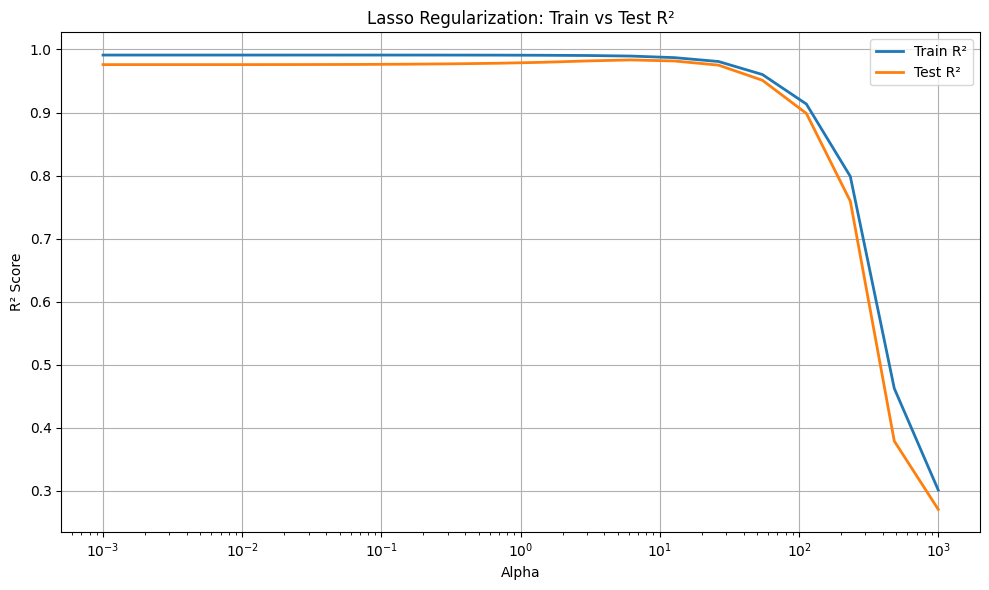

In [143]:
# Подберём гиперпараметры:
l_train = []
l_test = []
alphas = np.geomspace(1e-3, 1e3, 20)
for i in alphas:
    cv1 = cross_validate(Lasso(alpha=i, max_iter=10000), X=X_poly, y=y, scoring='r2', cv=5, return_train_score=True)
    l_train.append(np.mean(cv1['train_score']))
    l_test.append(np.mean(cv1['test_score']))


plt.figure(figsize=(10, 6))
plt.plot(alphas, l_train, label='Train R²', linewidth=2)
plt.plot(alphas, l_test, label='Test R²', linewidth=2)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('R² Score')
plt.title('Lasso Regularization: Train vs Test R²')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [144]:
cv_l = cross_validate(Lasso(alpha=10, max_iter=10000), X=X_poly, y=y, 
                      scoring={'r2' : 'r2', 'neg_mape' : make_scorer(mean_absolute_percentage_error, greater_is_better=False)}, 
                      cv=5, return_train_score=True)
print(f'R^2 на тренировочных фолдах: {np.round(np.mean(cv_l['train_r2']), 3)}')
print(f'R^2 на валидационных фолдах: {np.round(np.mean(cv_l['test_r2']), 3)}')
print(f'MAPE на тренировочных фолдах: {np.round(np.mean(-cv_l['train_neg_mape']) * 100, 3)}%')
print(f'MAPE на валидационных фолдах: {np.round(np.mean(-cv_l['test_neg_mape']) * 100, 3)}%')

R^2 на тренировочных фолдах: 0.988
R^2 на валидационных фолдах: 0.982
MAPE на тренировочных фолдах: 1.91%
MAPE на валидационных фолдах: 2.354%


После подбора гиперпараметра alpha результаты практически не изменились, это означает, что alpha по умолчанию = 1, очень хорошо справляется со своей задачей, однако мы видим, что при alpha = 10, разница между метрикой на валидационных и тренировочных фолдах минимальна, поэтому я отдам предпочтение alpha = 10.

### Задание 8.3. (2 балла)

Проделаем то же самое с $L_2$-регуляризацией.

Обучите модель `Ridge` из библиотеки `sklearn` на полученных полиномиальных факторах, предварительно стандартизировав факторы. 

Коэффициент регуляризации (`alpha`) подберите самостоятельно с помощью любого известного вам метода подбора гиперпаметров.

Используя кросс-валидацию оцените среднее значение выбранной вами метрики (или метрик) на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

In [145]:
cv = cross_validate(Ridge(), X=X_poly, y=y, 
                    scoring={'r2' : 'r2', 'neg_mape' : make_scorer(mean_absolute_percentage_error, greater_is_better=False)}, 
                    return_train_score=True, cv=5)
print(f'R^2 на тренировочных фолдах: {np.round(np.mean(cv['train_r2']), 3)}')
print(f'R^2 на валидационных фолдах: {np.round(np.mean(cv['test_r2']), 3)}')
print(f'MAPE на тренировочных фолдах: {np.round(np.mean(-cv['train_neg_mape']) * 100, 3)}%')
print(f'MAPE на валидационных фолдах: {np.round(np.mean(-cv['test_neg_mape']) * 100, 3)}%')

R^2 на тренировочных фолдах: 0.991
R^2 на валидационных фолдах: 0.977
MAPE на тренировочных фолдах: 1.781%
MAPE на валидационных фолдах: 2.734%


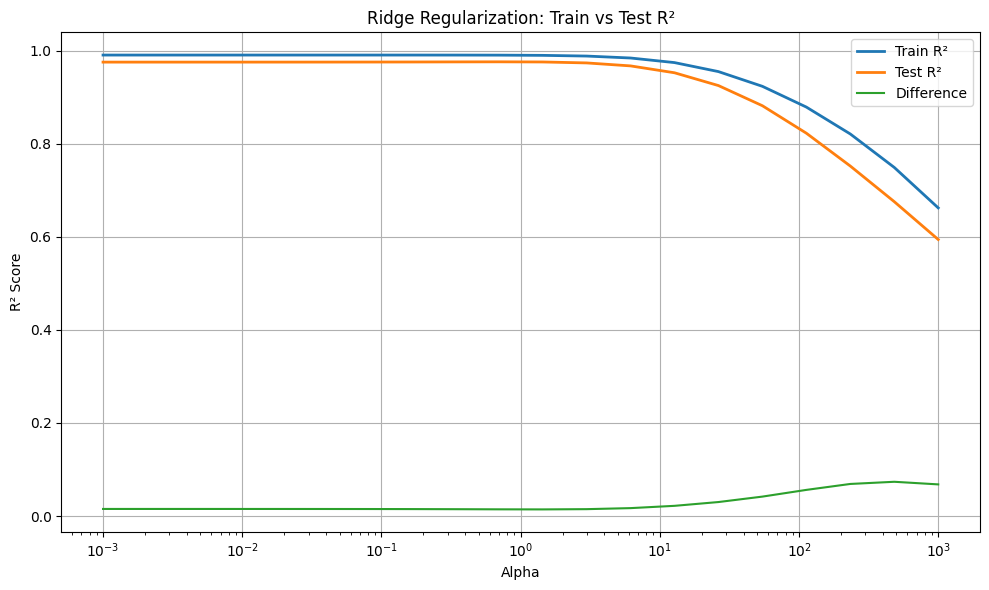

In [146]:
# Подберём гиперпараметры:
l_train = []
l_test = []
alphas = np.geomspace(1e-3, 1e3, 20)
for i in alphas:
    cv2 = cross_validate(Ridge(alpha=i, max_iter=10000), X=X_poly, y=y, scoring='r2', cv=5, return_train_score=True)
    l_train.append(np.mean(cv2['train_score']))
    l_test.append(np.mean(cv2['test_score']))


plt.figure(figsize=(10, 6))
plt.plot(alphas, l_train, label='Train R²', linewidth=2)
plt.plot(alphas, l_test, label='Test R²', linewidth=2)
plt.plot(alphas, np.array(l_train) - np.array(l_test), label='Difference')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('R² Score')
plt.title('Ridge Regularization: Train vs Test R²')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [147]:
cv_r = cross_validate(Ridge(alpha=1, max_iter=10000), X=X_poly, y=y, 
                      scoring={'r2' : 'r2', 'neg_mape' : make_scorer(mean_absolute_percentage_error, greater_is_better=False)}, 
                      cv=5, return_train_score=True)
print(f'R^2 на тренировочных фолдах: {np.round(np.mean(cv_r['train_r2']), 3)}')
print(f'R^2 на валидационных фолдах: {np.round(np.mean(cv_r['test_r2']), 3)}')
print(f'MAPE на тренировочных фолдах: {np.round(np.mean(-cv_r['train_neg_mape']) * 100, 3)}%')
print(f'MAPE на валидационных фолдах: {np.round(np.mean(-cv_r['test_neg_mape']) * 100, 3)}%')

R^2 на тренировочных фолдах: 0.991
R^2 на валидационных фолдах: 0.977
MAPE на тренировочных фолдах: 1.781%
MAPE на валидационных фолдах: 2.734%


Похожая ситуация наблюдается и у Ridge - регуляризации, однако в этом случае наша модель имеет примерно одинаковые метрики на диапазоне [10e-3 : 1], разница видна только на тысячных, что для наших целей является избыточной точностью

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**2 балла**): 
    * правильно построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках) с регуляризацией (Ridge), учтены условия необходимости масштабирования факторов для построения модели;
    * приведён код для подбора параметра регуляризации (вручную или с помощью библиотечных инструментов);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

### Задание 8.4. (2 балла)

Наконец, настало время комбинировать $L_1$ и $L_2$ -регуляризации.

Обучите модель `ElasticNet` из библиотеки `sklearn` на полученных полиномиальных факторах, предварительно стандартизировав факторы. 

Коэффициенты регуляризации (`alpha` и `l1-ratio`) подберите самостоятельно с помощью любого известного вам метода подбора гиперпаметров.

Используя кросс-валидацию, оцените среднее значение метрики MAPE на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**2 балла**): 
    * правильно построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках) с регуляризацией (ElasticNet), учтены условия необходимости масштабирования факторов для построения модели;
    * приведён код для подбора параметра регуляризации (вручную или с помощью библиотечных инструментов);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [148]:
cv = cross_validate(ElasticNet(), X=X_poly, y=y, 
                    scoring={'r2' : 'r2', 'neg_mape' : make_scorer(mean_absolute_percentage_error, greater_is_better=False)}, 
                    return_train_score=True, cv=5)
print(f'R^2 на тренировочных фолдах: {np.round(np.mean(cv['train_r2']), 3)}')
print(f'R^2 на валидационных фолдах: {np.round(np.mean(cv['test_r2']), 3)}')
print(f'MAPE на тренировочных фолдах: {np.round(np.mean(-cv['train_neg_mape']) * 100, 3)}%')
print(f'MAPE на валидационных фолдах: {np.round(np.mean(-cv['test_neg_mape']) * 100, 3)}%')


# Подбор гиперпараметров
grid_params = {'alpha' : np.geomspace(1e-3, 1e3, 10),
               'l1_ratio' : np.linspace(0.001, 1, 10)} 
grid_search = GridSearchCV(ElasticNet(max_iter=10000),
                           param_grid=grid_params,
                           cv=5,
                           scoring={'r2' : 'r2', 'MAPE' : make_scorer(mean_absolute_percentage_error, greater_is_better=False)},
                           refit='r2', return_train_score=True)

grid_search.fit(X_poly, y)

R^2 на тренировочных фолдах: 0.903
R^2 на валидационных фолдах: 0.855
MAPE на тренировочных фолдах: 6.135%
MAPE на валидационных фолдах: 7.268%


,estimator,ElasticNet(max_iter=10000)
,param_grid,"{'alpha': array([1.0000...00000000e+03]), 'l1_ratio': array([0.001,... 1. ])}"
,scoring,"{'MAPE': make_scorer(m...hod='predict'), 'r2': 'r2'}"
,n_jobs,None
,refit,'r2'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,alpha,10.0


In [149]:
results = pd.DataFrame(grid_search.cv_results_)
best_index = grid_search.best_index_


print(f'Лучшие параметры модели: {grid_search.best_params_}')
print(f'F1-score на тренировочных фолдах: {np.round(results.loc[best_index, 'mean_train_r2'], 3)}')
print(f'F1-score на валидационных фолдах: {np.round(results.loc[best_index, 'mean_test_r2'], 3)}')
print(f'MAPE на тренировочных фолдах: {np.round(-results.loc[best_index, 'mean_train_MAPE'] * 100, 3)}%')
print(f'MAPE на валидационных фолдах: {np.round(-results.loc[best_index, 'mean_test_MAPE'] * 100, 3)}%')

Лучшие параметры модели: {'alpha': 10.0, 'l1_ratio': 1.0}
F1-score на тренировочных фолдах: 0.988
F1-score на валидационных фолдах: 0.982
MAPE на тренировочных фолдах: 1.91%
MAPE на валидационных фолдах: 2.354%


Модель занулила второе ограничение и мы получили регуляризацию Lasso, так как данная модель имеет самую высокую метрику.
Отметим ещё тот факт, что все предыдущие модели по умлочанию имели очень хорошие гиперпараметры, которые можно было не подбирать заново, так как разница исчислялась сотыми, в отличие от ElasticNet, у которого R^2 < 0.9, а MAPE > 7%.

### Задание 8.5. (1 балл)

Завершением вашей работы будет сводная таблица результатов, которую вы представите на презентации заказчику Василию.

Составьте таблицу (DataFrame) со следующими столбцами (имена столбцов выберите самостоятельно):
* Наименование модели.
* Гиперпараметры (коэффициенты регуляризации, если таковые имеются), если нет — оставьте ячейку пустой.
* Использовались ли полиномиальные признаки при построении модели (Да/Нет или True/False).
* Значение выбранной метрики на тренировочных фолдах при кросс-валидации модели.
* Значение выбранной метрики на валидационных фолдах при кросс-валидации модели.

Сделайте финальный вывод по проделанной работе. Какая линейная модель из тех, что мы рассмотрели, показала наилучший результат с точки зрения качества на валидационных фолдах, а также с точки зрения переобученности?

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**1 балл**): 
    * верно составлена сводная таблица итоговых результатов построенных ранее моделей с указанными в задании столбцами;
    * приведены итоговые выводы по проделанной работе, указано, какая из рассмотренных моделей показала наилучший результат.

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [150]:
dict_model = [['Регрессия (без стандартизации)', '', 'Нет', '0.949', '0.940', '3.915%', '4.154%'],
              ['Регрессия (стандартизация)', '', 'Да', '0.991', '0.976', '1.698%', '2.665%'],
              ['Lasso (стандартизация)', 'alpha=10', 'Да', '0.988', '0.982', '1.910%', '2.354%'],
              ['Ridge (стандартизация)', 'alpha=1', 'Да', '0.991', '0.977', '1.781%', '2.734%'],
              ['ElasticNet (стандартизация)', 'alpha=10, l1_ratio=1', 'Да', '0.988', '0.982', '1.910%', '2.354%']]
column_names = ['Имя модели', 'Гиперпараметры', 'Полиномиальные признаки', 'R^2 train', 'R^2 test', 'MAPE train', 'MAPE test']
df = pd.DataFrame(dict_model, columns=column_names)
df

,Имя модели,Гиперпараметры,Полиномиальные признаки,R^2 train,R^2 test,MAPE train,MAPE test
0,Регрессия (без стандартизации),,Нет,0.949,0.940,3.915%,4.154%
1,Регрессия (стандартизация),,Да,0.991,0.976,1.698%,2.665%
2,Lasso (стандартизация),alpha=10,Да,0.988,0.982,1.910%,2.354%
3,Ridge (стандартизация),alpha=1,Да,0.991,0.977,1.781%,2.734%
4,ElasticNet (стандартизация),"alpha=10, l1_ratio=1",Да,0.988,0.982,1.910%,2.354%


Наилучшая модель регрессии из всех построенных - это Lasso со стандартизацией и полиномиальными признаками. она имеет минимальную разницу между тренировочными и валидационными фолдами, а также одни из наилучших метрик. Данная модель является оптимальной с точки зрения проблемы переобучения.